# 3 文本张量表示方法

### 学习目标
* 了解什么是文本张量表示及其作用.
* 掌握文本张量表示的几种方法及其实现.

---

## 1 文本张量表示

* 将一段文本使用张量进行表示，其中一般将词汇表示成向量，称作词向量，再由各个词向量按顺序组成矩阵形成文本表示.
* 举个例子：

> ["人生", "该", "如何", "起头"]
> 
> ==>
> 
> 每个词对应矩阵中的一个向量
>
> [[1.32, 4.32, 0.32, 5.2],
>  [3.1, 5.43, 0.34, 3.2],
>  [3.21, 5.32, 2, 4.32],
>  [2.54, 7.32, 5.12, 9.54]]

* **文本张量表示的作用：**
    * 将文本表示成张量（矩阵）形式，能够使语言文本可以作为计算机处理程序的输入，进行接下来一系列的解析工作。
* **文本张量表示的方法：**
    * one-hot编码
    * Word2vec
    * Word Embedding

## 2 one-hot词向量表示

* **又称独热编码**，将每个词表示成具有n个元素的向量，这个词向量中只有一个元素是1，其他元素都是0，不同词汇元素为0的位置不同，其中n的大小是整个语料中不同词汇的总数.
* **举个例子**：

> ["改变", "要", "如何", "起手"]
> 
> ==>
> 
> [[1, 0, 0, 0],
>
>  [0, 1, 0, 0],
>
>  [0, 0, 1, 0],
>
>  [0, 0, 0, 1]]

* **onehot编码实现**：
    * 进行onehot编码：

In [1]:
# 导入用于对象保存与加载的joblib
import joblib

# 导入keras中的词汇映射器Tokenizer
from keras.preprocessing.text import Tokenizer

# 假定vocab为语料集所有不同词汇集合
vocab = {"周杰伦", "陈奕迅", "王力宏", "李宗盛", "吴亦凡", "鹿晗"}

# 实例化一个词汇映射器对象
t = Tokenizer(num_words=None, char_level=False)

# 使用映射器拟合现有文本数据
t.fit_on_texts(vocab)

for token in vocab:
    zero_list = [0]*len(vocab)
    # 使用映射器转化现有文本数据，每个词汇对应从1开始的自然数
    # 返回样式如：[[2]]，取出其中的数字需要使用[0][0]
    token_index = t.texts_to_sequences([token])[0][0] - 1
    zero_list[token_index] = 1
    print(token, "的one-hot编码为:", zero_list)

# 使用joblib工具保存映射器，以便之后使用
tokenizer_path = "./Tokenizer"
joblib.dump(t, tokenizer_path)

ModuleNotFoundError: No module named 'tensorflow'

- 输出效果：

> 鹿晗 的 one-hot编码为：[[1, 0, 0, 0, 0, 0]]
> 
> 王力宏 的 one-hot编码为：[[0, 1, 0, 0, 0, 0]]
> 
> 李宗盛 的 one-hot编码为：[[0, 0, 1, 0, 0, 0]]
> 
> 陈奕迅 的 one-hot编码为：[[0, 0, 0, 1, 0, 0]]
> 
> 周杰伦 的 one-hot编码为：[[0, 0, 0, 0, 1, 0]]
> 
> 吴亦凡 的 one-hot编码为：[[0, 0, 0, 0.1, 0, 1]]
> 
> 同时在当前目录生成Tokenizer文件，以便之后使用

- onehot编码器的使用：

In [ ]:
# 加载之前保存的Tokenizer，实例化一个t对象
t = joblib.load(tokenizer_path)

# 编码token为“李宗盛”
token = "李宗盛"
# 使用t获得token_index
token_index = t.texts_to_sequences([token])[0][0] - 1
# 初始化一个zero_list
zero_list = [0]*len(vocab)
# 令zero_list的对应索引为1
zero_list[token_index] = 1
print(token, "的one-hot编码为:", zero_list)

- 输出效果：

李宗盛的 one-hot编码为：[[1, 0, 0, 0, 0, 0]]

- one-hot编码的优劣劣势：
  - 优势：操作简单，容易理解。
  - 劣势：完全割裂了词与词之间的联系，而且在大语料集下，每个向量的长度过大，占据大量内存。
  - 正因为one-hot编码明显的劣势，这种编码方式被应用的地方越来越少，取而代之的是接下来我们要学习的稠密向量的表示方法word2vec和word embedding。

# 3 word2vec模型

## 3.1 模型介绍

- word2vec是一种流行的将词汇表示成向量的无监督训练方法，该过程将构建神经网络模型，将网络参数作为词汇的向量表示，它包含CBOW和skipgram两种训练模式。

- CBOW(Continuous bag of words)模式：
  - 给定一段用于训练的文本语料，再选定某段长度(窗口)作为研究对象，使用上下文词汇预测目标词汇。

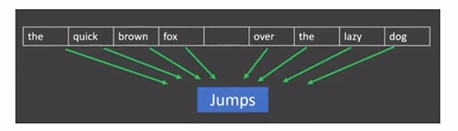

- 分析
- 图中窗口大小为9, 使用前后4个词汇对目标词汇进行预测。

- CBOW模式下的word2vec过程说明：

  - 假设我们给定的训练语料只有一句话: Hope can set you free (愿你自由成长)，窗口大小为3，因此模型的第一个训练样本来自Hope can set，因为是CBOW模式，所以将使用Hope和set作为输入，can作为输出，在模型训练时，Hope, can, set等词汇都使用它们的one-hot编码。如图所示: 每个one-hot编码的单词与各自的变换矩阵(即参数矩阵3x5, 这里的3是指最后得到的词向量维度)相乘之后再相加, 得到上下文表示矩阵(3x1)。

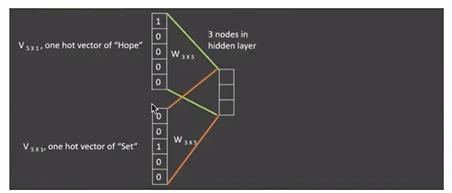

> 接着，将上下文表示矩阵与变换矩阵(参数矩阵5x3, 所有的变换矩阵共享参数)相乘，得到5x1的结果矩阵，它将与我们真正的目标矩阵即can的one-hot编码矩阵(5x1)进行损失的计算，然后更新网络参数完成一次模型迭代。

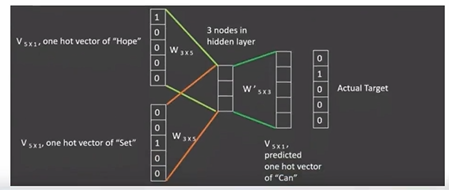

> 最后窗口按序向后移动，重新更新参数，直到所有语料被遍历完成，得到最终的变换矩阵(3x5)，这个变换矩阵与每个词汇的one-hot编码(5x1)相乘，得到的3x1的矩阵就是该词汇的word2vec张量表示。

- skipgram模式：
    - 给定一段用于训练的文本语料，再选定某段长度（窗口）作为研究对象，使用目标词汇预测上下文词汇。

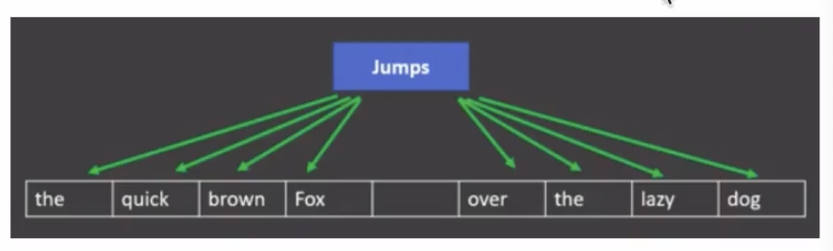

- 分析：
  - 图中窗口大小为9，使用目标词汇对前后四个词汇进行预测。

- skipgram模式下的word2vec过程说明：

  - 假设我们给定的训练语料只有一句话：Hope can set you free (愿你自由成长)，窗口大小为3，因此模型的第一个训练样本来自Hope can set，因为是skipgram模式，所以将使用can作为输入，Hope和set作为输出，在模型训练时，Hope、can、set等词汇都使用它们的one-hot编码。如图所示：将can的one-hot编码与变换矩阵(即参数矩阵3x5，这里的3是指最后得到的词向量维度)相乘，得到目标词汇表示矩阵(3x1)。

  - 接着，将目标词汇表示矩阵与多个变换矩阵(参数矩阵5x3)相乘，得到多个5x1的结果矩阵，它将与我们Hope和set对应的one-hot编码矩阵(5x1)进行损失的计算，然后更新网络参数完成一次模型迭代。

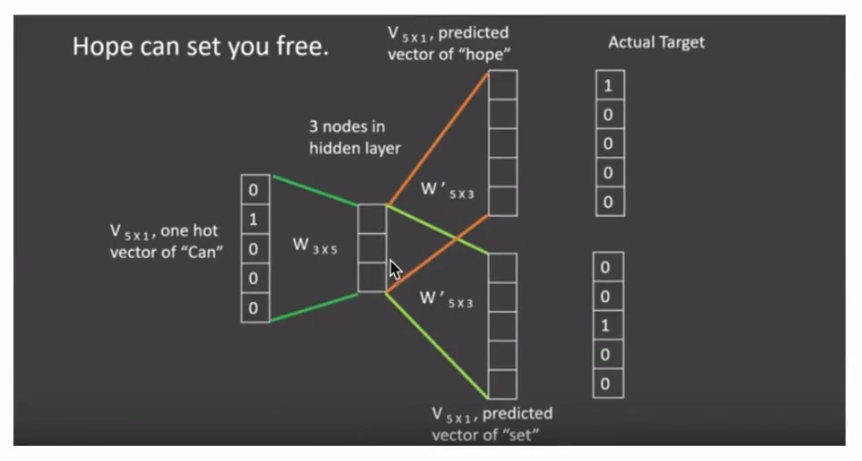

- 最后窗口按序向后移动，重新更新参数，直到所有语料被遍历完成，得到最终的变换矩阵即参数矩阵(3x5)，这个变换矩阵与每个词汇的one-hot编码(5x1)相乘，得到的3x1的矩阵就是该词汇的word2vec张量表示。

### 3.2 word2vec的训练和使用

- 第一步：获取训练数据  
- 第二步：训练词向量  
- 第三步：模型超参数设定  
- 第四步：模型效果检验  
- 第五步：模型的保存与重复加载  

#### 1 获取训练数据

数据来源：http://mattmahoney.net/dc/enwik9.zip  

在这里，我们将研究英语维基百科的部分网页信息，它的大小在300M左右。这些语料已经被准备好，我们可以通过Matt Mahoney的网站下载。

**注意：原始数据集enwik9.zip，解压后数据为enwik9，预处理后的数据为fil9**

> - 查看原始数据：



- 原始数据处理：

# 使用wikifil.pl文件处理脚本来清除XML/HTML格式的内容
# perl wikifil.pl data/enwik9 > data/fil9 #该命令已经执行

>$ head -10 data/enwik9
>
># 原始数据将输出很多包含XML/HTML格式的内容，这些内容并不是我们需要的

><mediawiki xmlns="http://www.mediawiki.org/xml/export-0.3/" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance">
>    <sitename>Wikipedia</sitename>
>    <base>http://en.wikipedia.org/wiki/Main_Page</base>
>    <generator>MediaWiki 1.6alpha</generator>
>    <case>first-letter</case>
>    <namespace>
>    <namespace key="-2">Media</namespace>
>    <namespace key="-1">Special</namespace>
>    <namespace key="0" />
>    </namespace>
> </sitename>

- 原始数据处理：

> 使用wikifil.pl文件处理脚本来清除XML/HTML格式的内容
> perl wikifil.pl data/envik9 > data/fil9 #该命令已经执行

- 查看预处理后的数据：

> 查看前80个字符
>
> head -c 80 data/fil9
>
> 输出结果为由空格分割的单词
>
> anarchism originated as a term of abuse first used against early working class

## 2 训练词向量

In [1]:
# 代码运行在python解释器中
# 导入fasttext
import fasttext
# 使用fasttext的train_unsupervised(无监督训练方法)进行词向量的训练
# 它的参数是数据集的持久化文件路径'data/fil9'

# 注意，该行代码执行时长很长
# model1 = fasttext.train_unsupervised('data/fil9')

# 可以使用以下代码加载已经训练好的模型
model = fasttext.load_model("data/fil9.bin")

# 有效训练词汇量为124M，共218316个单词
# Read 124M words
# Number of words: 218316
# Number of labels: 0
# Progress: 100.0% words/sec/thread: 53996 lr: 0.000000 loss: 0.734999 ETA:

## 3 查看单词对应的词向量

In [ ]:
# 通过get_word_vector方法来获得指定词汇的词向量
model.get_word_vector("the")

# array([-0.03087516,  0.09221972,  0.17660329,  0.17308897,  0.12863874,
#    0.13912526, -0.09851588,  0.00739991,  0.37038437, -0.00845221,
#     ...,
#     -0.21184735, -0.05048715, -0.34571868,  0.23765688,  0.23726143],
#     dtype=float32)

array([-0.04301041,  0.16814393,  0.22123878, -0.01933387,  0.12991922,
       -0.1293303 ,  0.02525317, -0.1740252 , -0.3066281 ,  0.13731436,
       -0.0662714 , -0.07624689,  0.0147622 ,  0.08076666, -0.19351703,
        0.26391718,  0.25678822, -0.12013761,  0.49363837, -0.02311194,
       -0.13697113,  0.01671061,  0.12590222,  0.11990301,  0.0484859 ,
        0.0347303 ,  0.11152679,  0.05908459,  0.09221677,  0.07636841,
        0.3952047 ,  0.68850434,  0.16746025,  0.10834347, -0.31667256,
        0.34315938, -0.20489104, -0.03983494,  0.08946229,  0.16979638,
        0.18670495,  0.09486821, -0.35485765, -0.07526183, -0.03372391,
       -0.02843935,  0.07033824,  0.0113048 ,  0.08931127,  0.05919867,
       -0.02960003, -0.28916177, -0.0112029 , -0.07929546,  0.11133678,
        0.13603906, -0.4072493 , -0.06643836,  0.03096501,  0.05426566,
        0.53903437,  0.26233444,  0.09545606,  0.07989341,  0.06623864,
        0.24807042, -0.02206453, -0.50059783, -0.2507903 , -0.03

## 4 模型超参数设定

In [ ]:
# 在训练词向量过程中，我们可以设定很多常用超参数来调节我们的模型效果，如：
# 无监督训练模式：`skipgram` 或者 `cbow`，默认为 `skipgram`，在实践中，skipgram模式在利用
# 词嵌入维度dim：默认为100，但随着语料库的增大，词嵌入的维度往往也要更大。
# 数据循环次数epoch：默认为5，但当你的数据集足够大，可能不需要那么多次。
# 学习率lr：默认为0.05，根据经验，建议选择[0.01, 1]范围内。
# 使用的线程数thread：默认为12个线程，一般建议和你的cpu核数相同。

model = fasttext.train_unsupervised('data/fil9', "cbow", dim=300, epoch=1, lr=0.1, thread=8)

# Read 124M words
# Number of words: 218316
# Number of labels: 0
# Progress: 100.0% words/sec/thread: 49523 lr: 0.000000 avg.loss: 1.777205 ETA

## 5模型效果检验

In [5]:
# 检查单词向量质量的一种简单方法就是查看其邻近单词，通过我们主观来判断这些邻近单词是否与目标单词接近

# 查找“运动”的邻近单词，我们可以发现“体育网”、“运动汽车”、“运动服”等。
model.get_nearest_neighbors('sports')

# 查找“音乐”的邻近单词，我们可以发现与音乐有关的词汇。
model.get_nearest_neighbors('music')

# 查找“小狗”的邻近单词，我们可以发现与小狗有关的词汇。
model.get_nearest_neighbors('dog')

[(0.9157814383506775, 'dogs'),
 (0.909575343132019, 'dou'),
 (0.9054428935050964, 'doo'),
 (0.8941407203674316, 'doge'),
 (0.8840115070343018, 'doggy'),
 (0.8756324052810669, 'doubt'),
 (0.8737891912460327, 'dojo'),
 (0.8698852062225342, 'doi'),
 (0.8658696413040161, 'dogg'),
 (0.8633419275283813, 'dowd')]

## 6 模型的保存与重加载

In [ ]:
# 使用save_model保存模型
model.save_model("fil9.bin")

# 使用fasttext.load_model加载模型
model = fasttext.load_model("fil9.bin")
model.get_word_vector("the")

# 4 词嵌入word embedding介绍

- 通过一定的方式将词汇映射到指定维度(一般是更高维度)的空间。
- 广义的word embedding包括所有密集词汇向量的表示方法，如之前学习的word2vec，即可以为是word embedding的一种。
- 狭义的word embedding是指在神经网络中加入的embedding层，对整个网络进行训练的同时产生的embedding矩阵(embedding层的参数)，这个embedding矩阵就是训练过程中所有输入词汇的向量表示组成的矩阵。